In [1]:
!pip install bertopic
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5

In [357]:
import pandas as pd
import numpy as np
import torch
import transformers
from bertopic import BERTopic
import os
from sentence_transformers import SentenceTransformer
from umap import UMAP
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import openai
import lightgbm as lgb
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [358]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [359]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [360]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df1 = pd.read_csv('../data/letters_2021_processed.csv')
df1 = df1[['s1_s2', 'full_text', 'LETTER_GENDER']]
df1 = df1.rename(columns={'LETTER_GENDER':'label'})

In [361]:
df2 = pd.read_csv('../data/sentence_sets_trimmed_processed.csv')
df2 = df2[['s1_s2', 'full_text', 'applicant_gender']]
df2 = df2.rename(columns={'applicant_gender':'label'})

In [362]:
df = pd.concat([df1, df2], ignore_index=True)

In [363]:
gender_label_mapping = {
    'F':0,
    'female':0,
    'M':1,
    'male':1
}

In [364]:
df['label'] = df['label'].replace(gender_label_mapping)

# Process Data

In [365]:
letters = df['s1_s2']
sentences = [sent_tokenize(letter) for letter in letters]
sentences = pd.concat([df, pd.Series(sentences, name='sentences')], axis=1)
sentences = sentences[['sentences']].explode('sentences')
df_sentences = pd.merge(df, sentences, left_index=True, right_index=True)

# Topic Modeling

In [512]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(sentences['sentences'].tolist(), show_progress_bar=True)

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

hdbscan_model = HDBSCAN(min_cluster_size=150, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

vectorizer_model = CountVectorizer(stop_words="english", min_df=2, ngram_range=(1, 3))

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

Batches:   0%|          | 0/4850 [00:00<?, ?it/s]

In [513]:
# KeyBERT
keybert_model = KeyBERTInspired()

# Part-of-Speech
pos_model = PartOfSpeech("en_core_web_sm")

# MMR
mmr_model = MaximalMarginalRelevance(diversity=0.9)

# GPT-3.5
client = openai.OpenAI(api_key="sk-...")
prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Make sure it is in the following format:
topic: <topic label>
"""
openai_model = OpenAI(client, model="gpt-3.5-turbo", exponential_backoff=True, chat=True, prompt=prompt)

# All representation models
representation_model = {
    "KeyBERT": keybert_model,
    # "OpenAI": openai_model,  # Uncomment if you will use OpenAI
    "MMR": mmr_model,
    "POS": pos_model
}

In [514]:
topic_model = BERTopic(

  # Pipeline models
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  vectorizer_model=vectorizer_model,
  # ctfidf_model=ctfidf_model,
  representation_model=representation_model,

  # Hyperparameters
  top_n_words=10,
  verbose=True
)

# Train model
topics, probs = topic_model.fit_transform(df_sentences['sentences'].tolist(), embeddings)



2025-02-05 18:07:23,978 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-02-05 18:12:20,813 - BERTopic - Dimensionality - Completed ✓
2025-02-05 18:12:20,820 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-02-05 18:12:57,456 - BERTopic - Cluster - Completed ✓
2025-02-05 18:12:57,519 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-02-05 18:13:28,283 - BERTopic - Representation - Completed ✓


# Analyze Topics

In [515]:
topic_info = topic_model.get_topic_info()

In [516]:
topic_info

,Topic,Count,Name,Representation,KeyBERT,MMR,POS,Representative_Docs
0,-1,57167,-1_identifier_medical_work_research,"[identifier, medical, work, research, clinical...","[dr identifier, identifier, identifier identif...","[medical, research, worked, care, students, id...","[identifier, medical, research, clinical, medi...","[ identifier identifier ., identifier am ..."
1,0,11715,0_anesthesiology_anesthesia_identifier_residency,"[anesthesiology, anesthesia, identifier, resid...","[identifier anesthesiology residency, identifi...","[rotation, program, recommend identifier, anes...","[anesthesiology, anesthesia, identifier, resid...",[| highly recommend identifier for an anesth...
2,1,10927,1_patients_patient_care_clinical,"[patients, patient, care, clinical, knowledge,...","[patients families, care patients, patients st...","[care, able, manner, families, medical knowled...","[patients, patient, care, clinical, knowledge,...",[they has an excellent bedside manner with th...
3,2,9940,2_anesthesia_anesthesiology_anesthesiologist_c...,"[anesthesia, anesthesiology, anesthesiologist,...","[future anesthesiologist, career anesthesiolog...","[field, residency, believe, rotation, career a...","[anesthesia, anesthesiology, anesthesiologist,...",[although | would love their to pursue surge...
4,3,3915,3_patients_patient_patients identifier_care,"[patients, patient, patients identifier, care,...","[care patients identifier, patient care identi...","[demonstrated, staff, skills, empathy, familie...","[patients, patient, care, identifier, patient ...",[identifier demonstrated outstanding patient ...
...,...,...,...,...,...,...,...,...
95,94,161,94_pgy_preliminary_preliminary pgy_pgy1,"[pgy, preliminary, preliminary pgy, pgy1, pgy ...","[identifier currently pgy, identifier pgy, pre...","[identifier currently, currently, general, yea...","[preliminary, pgy1, surgery, resident, soap, g...",[identifier is currently a pgy - 1 preliminar...
96,95,159,95_lam_lam writing_program lam_lam writing letter,"[lam, lam writing, program lam, lam writing le...","[identifier lam, lam writing letter, letter su...","[program lam, support, recommendation, residen...","[letter, support, recommendation, residency, i...",[lam writing a letter of recommendation for i...
97,96,156,96_navy_flight_officer_military,"[navy, flight, officer, military, air, army, m...","[awarded navy, navy marine corps, navy marine,...","[officer, air, flight surgeon, combat, marine ...","[navy, flight, officer, military, air, marine,...",[they was awarded both the navy and marine co...
98,97,156,97_ultrasound_nerve_blocks_nerve blocks,"[ultrasound, nerve, blocks, nerve blocks, bloc...","[ultrasound guided nerve, guided nerve blocks,...","[block, epidural, regional, structures, care u...","[ultrasound, nerve, blocks, block, epidural, p...","[as the month progressed , they went from as..."


In [517]:
topic_model.get_topic(10, full=True)

{'Main': [('person', 0.028628572049971535),
  ('individual', 0.02690032730213965),
  ('personality', 0.02067166087697133),
  ('identifier', 0.0196442599667764),
  ('demeanor', 0.01689774944948658),
  ('young person', 0.01677623289599611),
  ('motivated', 0.016425889963598016),
  ('intelligent', 0.016098338704535187),
  ('individual identifier', 0.01572320516906521),
  ('humble', 0.015590538381753099)],
 'KeyBERT': [('identifier intelligent', 0.73673457),
  ('identifier friendly', 0.7293787),
  ('identifier', 0.71875304),
  ('personality identifier', 0.7061554),
  ('individual identifier', 0.7044524),
  ('identifier personable', 0.7033792),
  ('identifier extremely', 0.6850225),
  ('identifier pleasant', 0.68295264),
  ('young person identifier', 0.6805347),
  ('identifier polite', 0.6803214)],
 'MMR': [('person', 0.028628572049971535),
  ('motivated', 0.016425889963598016),
  ('intelligent', 0.016098338704535187),
  ('humble', 0.015590538381753099),
  ('young', 0.014779330349110545),
 

In [534]:
topic_labels = topic_model.generate_topic_labels(nr_words=5,
                                                 topic_prefix=True,
                                                 word_length=20,
                                                 separator="||",
                                                 aspect='MMR')

In [535]:
topic_model.set_topic_labels(topic_labels)

In [536]:
topic_mapping = dict(zip(topic_model.get_topic_info()['Topic'], topic_model.get_topic_info()['CustomName']))
topic_mapping = {f'topic_{key}': value for key, value in topic_mapping.items()}

In [537]:
df_sentences['topic'] = topics

# Create Topics Dataframe

In [538]:
topics_df = df_sentences.copy()
topics_df['topic'] = topics_df['topic'].astype(str)
topics_df = topics_df.groupby(topics_df.index).agg({'topic':' '.join})
topics_df = pd.DataFrame(topics_df)
topics_df = topics_df['topic'].apply(lambda x:x.split(' '))
topics_df = topics_df.reset_index()
all_topics = set(cat for sublist in topics_df['topic'] for cat in sublist)
for topic in all_topics:
    topics_df[topic] = topics_df['topic'].apply(lambda x: 1 if topic in x else 0)
topics_df = topics_df.drop(columns=['index', 'topic'])
topics_df.columns = 'topic_' + topics_df.columns
df_sentences_collapsed = df_sentences[['s1_s2', 'full_text', 'label']].drop_duplicates()
topics_df = pd.merge(df_sentences_collapsed, topics_df, left_index=True, right_index=True)

<ipython-input-538-c6b868006b56>:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  topics_df[topic] = topics_df['topic'].apply(lambda x: 1 if topic in x else 0)
<ipython-input-538-c6b868006b56>:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  topics_df[topic] = topics_df['topic'].apply(lambda x: 1 if topic in x else 0)


# Build ML Model

In [539]:
X = topics_df.drop(columns=['s1_s2', 'full_text', 'label'])
y = topics_df['label']

In [540]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [541]:
skf = StratifiedKFold(n_splits=5)

In [542]:
# clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf = lgb.LGBMClassifier(is_unbalance=True, verbose=-1)

In [543]:
best_classifier = None
best_f1_score = float('-inf')
for i, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    print(f"Fold {i}:")
    # print(f"  Train: index={train_index}")
    # print(f"  Test:  index={val_index}")

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    clf.fit(X_train_fold, y_train_fold)

    y_pred = clf.predict(X_val_fold)

    print(classification_report(y_val_fold, y_pred))

    print(confusion_matrix(y_val_fold, y_pred))

    f1 = f1_score(y_val_fold, y_pred, average='weighted')

    if f1 > best_f1_score:
      print('BEST F1 SCORE: ', f1)
      best_f1_score = f1
      best_classifier = clf






Fold 0:
              precision    recall  f1-score   support

           0       0.34      0.41      0.37       446
           1       0.70      0.63      0.67       991

    accuracy                           0.56      1437
   macro avg       0.52      0.52      0.52      1437
weighted avg       0.59      0.56      0.57      1437

[[183 263]
 [363 628]]
BEST F1 SCORE:  0.5747537759197697
Fold 1:
              precision    recall  f1-score   support

           0       0.34      0.41      0.37       446
           1       0.71      0.64      0.67       991

    accuracy                           0.57      1437
   macro avg       0.52      0.52      0.52      1437
weighted avg       0.59      0.57      0.58      1437

[[183 263]
 [359 632]]
BEST F1 SCORE:  0.577166523830001
Fold 2:
              precision    recall  f1-score   support

           0       0.31      0.35      0.33       446
           1       0.69      0.64      0.66       991

    accuracy                           0.55

Most Important Features:
                                              Feature  Importance
54  1||care||able||manner||families||medical knowl...         186
51  2||field||residency||believe||rotation||career...         174
44  4||residency program id||position||candidate||...         157
94  3||demonstrated||staff||skills||empathy||families         153
91  0||rotation||program||recommend identifier||an...         119
98    6||program||asset||addition||recommend||believe         106
32  8||calm||hard||motivated||personality||communi...          91
88  10||person||motivated||intelligent||humble||young          71
69  11||medical student iden||best medical||studen...          68
55  5||mx identifier||pleasure||letter||mx pleasur...          61
18     13||bachelor||school||medicine||cum||currently          58
60  17||reservation||asset program||recommend iden...          55
41  15||recommendation||letter recommendatio||plea...          53
17  27||room||operating room staff||environment||t.

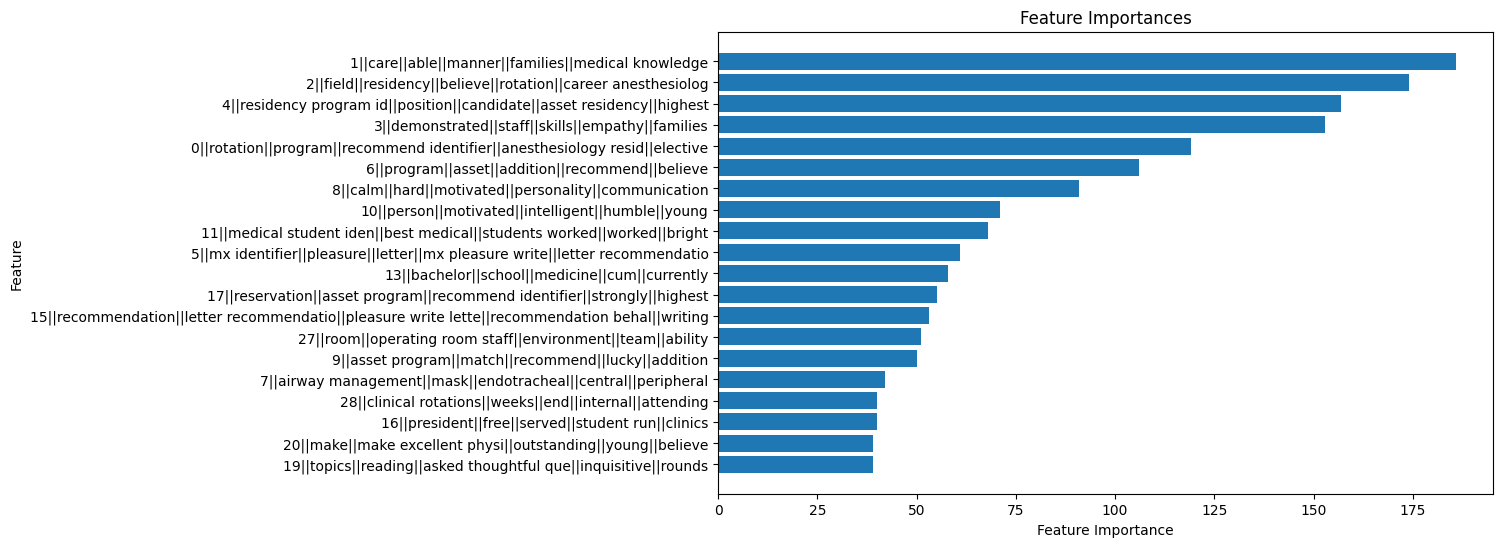

In [548]:
importances = best_classifier.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)[:20]
feature_importance_df['Feature'] = feature_importance_df['Feature'].map(topic_mapping)

print("Most Important Features:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')

plt.gca().invert_yaxis()

plt.show()

In [545]:
topic_model.get_topic(3, full=True)

{'Main': [('patients', 0.02427817885523417),
  ('patient', 0.020753583377652558),
  ('patients identifier', 0.015089917136237072),
  ('care', 0.013244250343461189),
  ('identifier', 0.013153624454004519),
  ('patient care', 0.00941431149973346),
  ('clinical', 0.009120124648098566),
  ('knowledge', 0.0075027367755731225),
  ('care identifier', 0.007198586416258273),
  ('demonstrated', 0.006730680276839637)],
 'KeyBERT': [('care patients identifier', 0.75344133),
  ('patient care identifier', 0.7283373),
  ('patients identifier', 0.69445485),
  ('patient identifier', 0.66892564),
  ('care identifier', 0.6392102),
  ('care patients', 0.6286762),
  ('patient care', 0.5866648),
  ('patients', 0.57396024),
  ('patient', 0.51151973),
  ('patients staff', 0.49089605)],
 'MMR': [('demonstrated', 0.006730680276839637),
  ('staff', 0.006620636087306474),
  ('skills', 0.006384675470353785),
  ('empathy', 0.006320867480452692),
  ('families', 0.006178894268079883),
  ('able', 0.006162792632735508)

# Apply on Test Set

In [546]:
y_test_preds = best_classifier.predict(X_test)

In [547]:
print(classification_report(y_test, y_test_preds))

              precision    recall  f1-score   support

           0       0.34      0.46      0.39       557
           1       0.71      0.60      0.65      1239

    accuracy                           0.56      1796
   macro avg       0.53      0.53      0.52      1796
weighted avg       0.60      0.56      0.57      1796

